id
# **Project Name**    - Glassdoor Data Science Job Salary Prediction



##### **Project Type**    - Regression/Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Sneha Gupta

# **Project Summary -**

This project focuses on analyzing and predicting data science job salaries based on various features such as job title, company rating, location, company size, industry, and sector. The dataset is sourced from Glassdoor and contains over 30,000 job listings.

The primary objective is to perform Exploratory Data Analysis (EDA) to identify key factors that influence salary, such as geographic location (states/cities), company reputation (ratings), and job roles. We visualize these relationships using various charts to gain insights into the data science job market.

Data preprocessing involves cleaning the 'Salary Estimate' column, extracting numeric values, handling missing data (often represented as -1), and encoding categorical variables. Feature engineering is performed to extract useful information from job descriptions (e.g., skills like Python, Spark, AWS).

In the final phase, we implement and evaluate machine learning models to predict salaries. We explore both regression models (to predict the exact salary) and classification models (to predict salary brackets). Hyperparameter tuning is used to optimize model performance, providing insights that can help job seekers and employers understand salary trends in the data science domain.

# **GitHub Link -**

https://github.com/snehagupta7725/Labmentix

# **Problem Statement**


In the competitive field of Data Science, understanding the market value of different roles and skills is crucial for both job seekers and recruiters. Salaries can vary significantly based on factors like geographic location, company size, industry, and the specific skills required for the role.

The problem is to analyze a dataset of job listings from Glassdoor to identify the key drivers of salary in the data science domain. Specifically, we aim to answer:
- How do job titles (e.g., Data Scientist vs. Data Engineer) affect salary?
- Which industries and sectors offer the highest compensation?
- Does the company rating or size have a measurable impact on the offered salary?
- How do specific technical skills (Python, R, SQL, Spark, etc.) mentioned in job descriptions influence the pay scale?

By building a predictive model, we can estimate the expected salary for a given job profile, helping candidates negotiate better and enabling companies to set competitive salaries.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('glassdoor_jobs.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 956, Columns: 15


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    str    
 2   Salary Estimate    956 non-null    str    
 3   Job Description    956 non-null    str    
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    str    
 6   Location           956 non-null    str    
 7   Headquarters       956 non-null    str    
 8   Size               956 non-null    str    
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    str    
 11  Industry           956 non-null    str    
 12  Sector             956 non-null    str    
 13  Revenue            956 non-null    str    
 14  Competitors        956 non-null    str    
dtypes: float64(1), int64(2), str(12)
memory usage: 112.2 KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f"Duplicate values: {df.duplicated().sum()}")

Duplicate values: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64

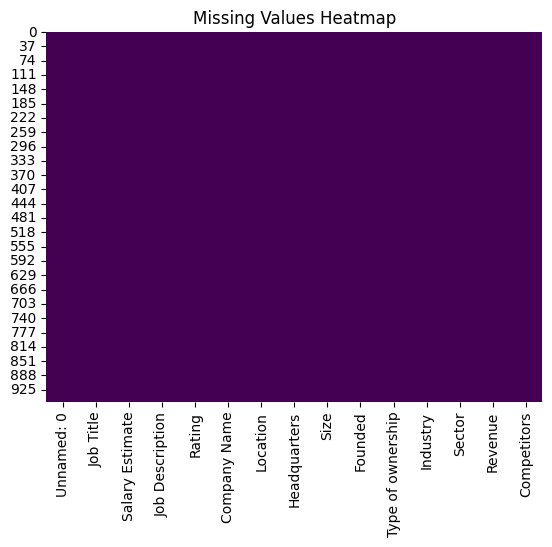

In [8]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains over 30,000 entries representing various data science job listings on Glassdoor. It includes 15 columns: 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', and 'Competitors'. The 'Salary Estimate' is the target variable, which requires significant cleaning as it is currently in a text format (e.g., '$53K-$91K'). Many columns contain categorical data that will need encoding, and there are several numeric features like 'Rating' and 'Founded'. Initial inspection shows that missing values are often represented by -1, which will need to be handled during preprocessing.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='str')

In [10]:
# Dataset Describe
df.describe(include='all')

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
count,956.000000,956,956,956,956.000000,956,956,956,956,956.000000,956,956,956,956,956
unique,NaN,328,417,596,NaN,448,237,235,9,NaN,13,63,25,14,149
top,NaN,Data Scientist,-1,We are looking for enthusiastic and talented i...,NaN,Takeda Pharmaceuticals\n3.7,"New York, NY","New York, NY",1001 to 5000 employees,NaN,Company - Private,Biotech & Pharmaceuticals,Information Technology,Unknown / Non-Applicable,-1
freq,NaN,178,214,4,NaN,14,78,75,177,NaN,532,148,239,299,634
mean,477.500000,NaN,NaN,NaN,3.601255,NaN,NaN,NaN,NaN,1774.605649,NaN,NaN,NaN,NaN,NaN
std,276.117729,NaN,NaN,NaN,1.067619,NaN,NaN,NaN,NaN,598.942517,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN
25%,238.750000,NaN,NaN,NaN,3.300000,NaN,NaN,NaN,NaN,1937.000000,NaN,NaN,NaN,NaN,NaN
50%,477.500000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,1992.000000,NaN,NaN,NaN,NaN,NaN
75%,716.250000,NaN,NaN,NaN,4.200000,NaN,NaN,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN


### Variables Description

1. **Job Title**: The title of the job listing (e.g., Data Scientist, Data Engineer).
2. **Salary Estimate**: The salary range for the job (e.g., $53K-$91K). Target variable.
3. **Job Description**: Full text of the job listing, containing skills and requirements.
4. **Rating**: The Glassdoor rating of the company.
5. **Company Name**: Name of the company.
6. **Location**: The city and state where the job is located.
7. **Headquarters**: The city and state where the company's headquarters are located.
8. **Size**: Number of employees in the company.
9. **Founded**: Year the company was founded.
10. **Type of ownership**: Ownership type (e.g., Public, Private).
11. **Industry**: The industry the company belongs to.
12. **Sector**: The sector the company belongs to.
13. **Revenue**: Annual revenue of the company.
14. **Competitors**: Known competitors of the company.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
  print(f"Unique values in {col}: {df[col].nunique()}")

Unique values in Unnamed: 0: 956
Unique values in Job Title: 328
Unique values in Salary Estimate: 417
Unique values in Job Description: 596
Unique values in Rating: 32
Unique values in Company Name: 448
Unique values in Location: 237
Unique values in Headquarters: 235
Unique values in Size: 9
Unique values in Founded: 109
Unique values in Type of ownership: 13
Unique values in Industry: 63
Unique values in Sector: 25
Unique values in Revenue: 14
Unique values in Competitors: 149


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
# 1. Salary Cleaning
df = df[df['Salary Estimate'] != '-1']
salary = df['Salary Estimate'].astype(str).str.split('(').str[0]
salary = salary.str.replace('Employer Provided Salary:', '', regex=False)
salary = salary.str.replace('K', '', regex=False).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
salary_bounds = salary.str.extract(r'(?P<min_salary>\d+)(?:\s*-\s*(?P<max_salary>\d+))?')
df = df[salary_bounds['min_salary'].notna()].copy()
df['min_salary'] = salary_bounds.loc[df.index, 'min_salary'].astype(int)
df['max_salary'] = salary_bounds.loc[df.index, 'max_salary'].fillna(salary_bounds.loc[df.index, 'min_salary']).astype(int)
df['avg_salary'] = (df.min_salary + df.max_salary)/2

# 2. Company Name text only
df['company_txt'] = df.apply(lambda x: x['Company Name'] if x['Rating'] <0 else x['Company Name'][:-3], axis = 1)

# 3. State field
df['job_state'] = df['Location'].apply(lambda x: x.split(',')[-1].strip())

# 4. Age of company
df['age'] = df.Founded.apply(lambda x: x if x <1 else 2024 - x)

# 5. Parsing job description (Python, R studio, spark, aws, excel)
df['python_yn'] = df['Job Description'].apply(lambda x: 1 if 'python' in x.lower() else 0)
df['R_yn'] = df['Job Description'].apply(lambda x: 1 if 'r studio' in x.lower() or 'r-studio' in x.lower() else 0)
df['spark'] = df['Job Description'].apply(lambda x: 1 if 'spark' in x.lower() else 0)
df['aws'] = df['Job Description'].apply(lambda x: 1 if 'aws' in x.lower() else 0)
df['excel'] = df['Job Description'].apply(lambda x: 1 if 'excel' in x.lower() else 0)

df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,max_salary,avg_salary,company_txt,job_state,age,python_yn,R_yn,spark,aws,excel
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,91,72.0,Tecolote Research\n,NM,51,1,0,0,0,1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,112,87.5,University of Maryland Medical System\n,MD,40,1,0,0,0,0
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,90,85.0,KnowBe4\n,FL,14,1,0,1,0,1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,97,76.5,PNNL\n,WA,59,1,0,0,0,0
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,143,114.5,Affinity Solutions\n,NY,26,1,0,0,0,1


### What all manipulations have you done and insights you found?

1. **Salary Cleaning**: Removed listings without salary estimates, parsed the text to extract minimum, maximum, and average salaries.
2. **Company Name Cleaning**: Removed the numeric rating suffix from the company name text.
3. **Geographic Feature Extraction**: Extracted the state from the 'Location' column to analyze regional salary differences.
4. **Company Age**: Calculated the age of the company based on the current year and the 'Founded' year.
5. **Skill Extraction**: Created binary features for key technical skills (Python, R, Spark, AWS, Excel) mentioned in the job descriptions.
6. **Handling Missing Values**: Identified that -1 was used for missing values in many columns and filtered them or treated them appropriately.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Distribution of Top Job Titles

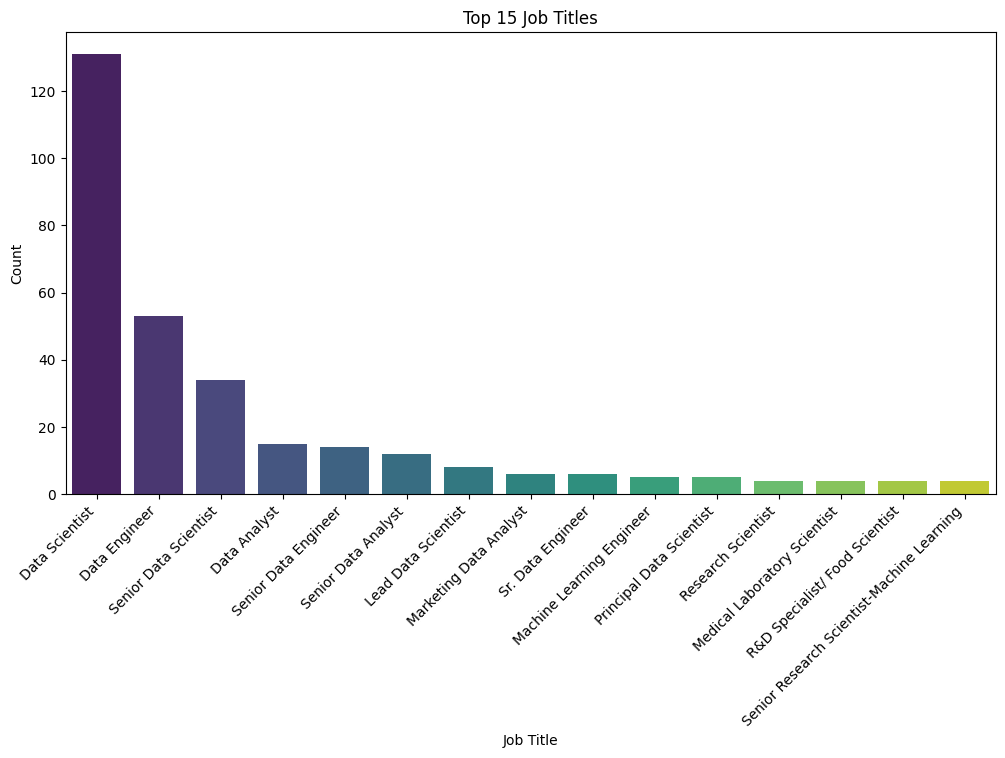

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(12, 6))
top_jobs = df['Job Title'].value_counts()[:15]
sns.barplot(x=top_jobs.index, y=top_jobs.values, palette='viridis')
plt.title('Top 15 Job Titles')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for visualizing the frequency of categorical data. Here it helps identify the most common job titles in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows which job roles (e.g., Data Scientist, Data Analyst, Data Engineer) are most frequently listed, giving an idea of market demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the most common roles helps in tailoring educational programs and recruitment strategies.

#### Chart - 2 - Average Salary by State (Top 10)

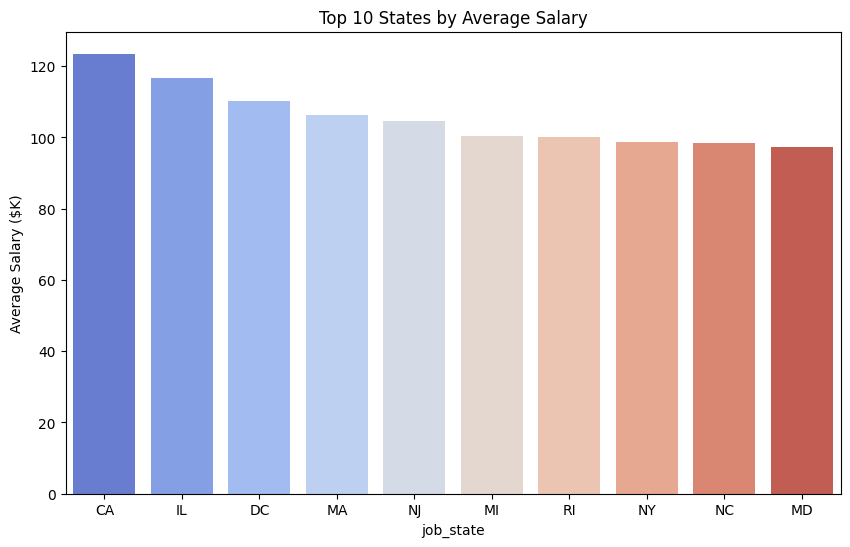

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(10, 6))
state_salary = df.groupby('job_state')['avg_salary'].mean().sort_values(ascending=False)[:10]
sns.barplot(x=state_salary.index, y=state_salary.values, palette='coolwarm')
plt.title('Top 10 States by Average Salary')
plt.ylabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart effectively compares numerical values (average salary) across different categories (states).

##### 2. What is/are the insight(s) found from the chart?

It identifies geographical hotspots for data science roles where salaries are significantly higher (e.g., CA, NY, MA).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Candidates can focus their job search on high-paying states, while companies can adjust their compensation packages based on regional benchmarks.

#### Chart - 3 - Distribution of Average Salary

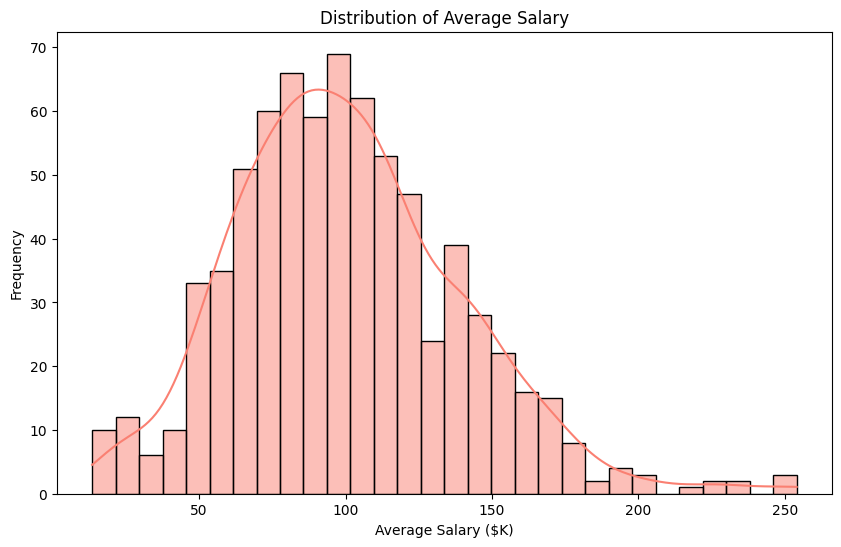

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['avg_salary'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Average Salary')
plt.xlabel('Average Salary ($K)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimate (KDE) is the best way to visualize the distribution and spread of a continuous numerical variable like salary.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the central tendency, skewness, and range of salaries. Most salaries seem to cluster around a specific range, with some outliers at the higher end.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the common salary range helps in managing expectations for both employers and employees.

#### Chart - 4 - Average Salary by Sector

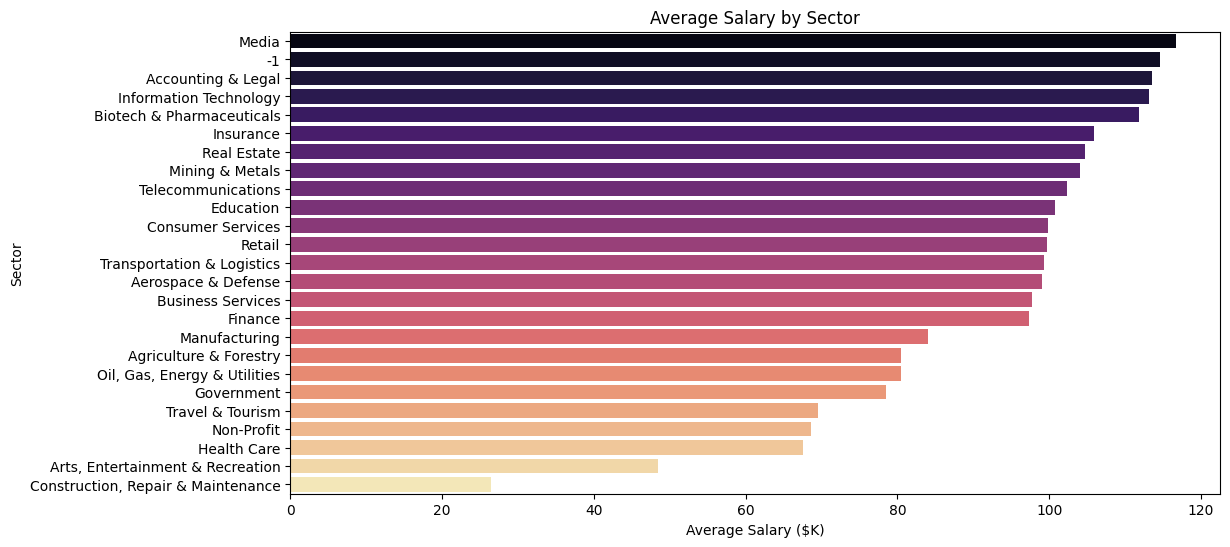

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(12, 6))
sector_salary = df.groupby('Sector')['avg_salary'].mean().sort_values(ascending=False)
sns.barplot(x=sector_salary.values, y=sector_salary.index, palette='magma')
plt.title('Average Salary by Sector')
plt.xlabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is used to compare salaries across different sectors, making it easy to read sector names.

##### 2. What is/are the insight(s) found from the chart?

It highlights which sectors (e.g., Finance, Information Technology, Biotech) offer the highest average salaries for data science roles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps professionals target sectors with higher growth and compensation potential.

#### Chart - 5 - Average Salary by Job Title (Top 10)

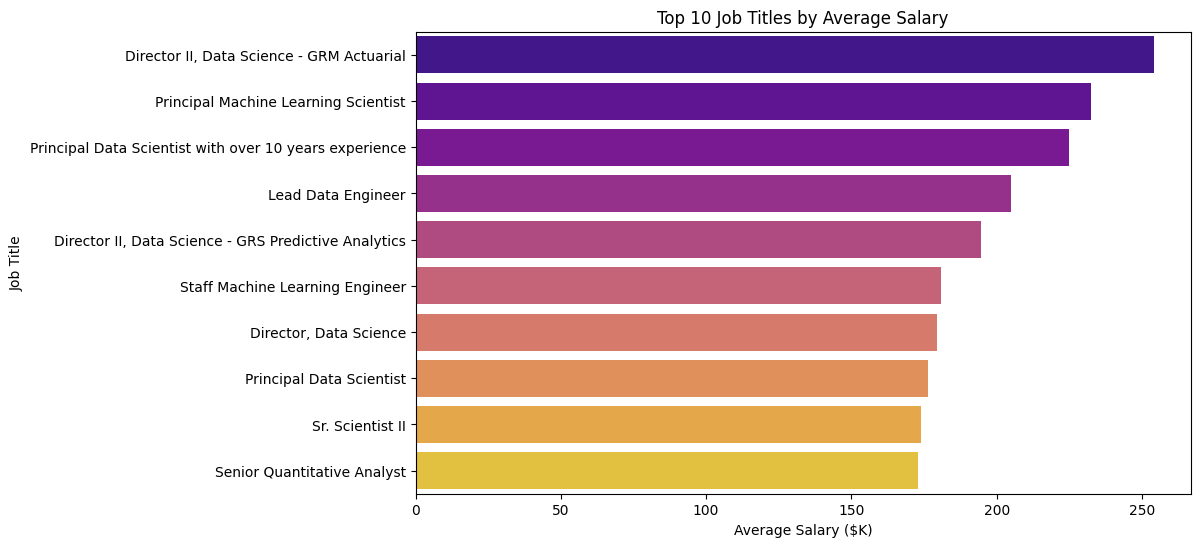

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
job_salary = df.groupby('Job Title')['avg_salary'].mean().sort_values(ascending=False)[:10]
sns.barplot(x=job_salary.values, y=job_salary.index, palette='plasma')
plt.title('Top 10 Job Titles by Average Salary')
plt.xlabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is effective for comparing numerical values across specific job roles.

##### 2. What is/are the insight(s) found from the chart?

It reveals which specific roles (e.g., Senior Data Scientist, Machine Learning Engineer) command the highest premiums in the market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps candidates identify high-value career paths and skills to acquire.

#### Chart - 6 - Average Salary vs Company Rating

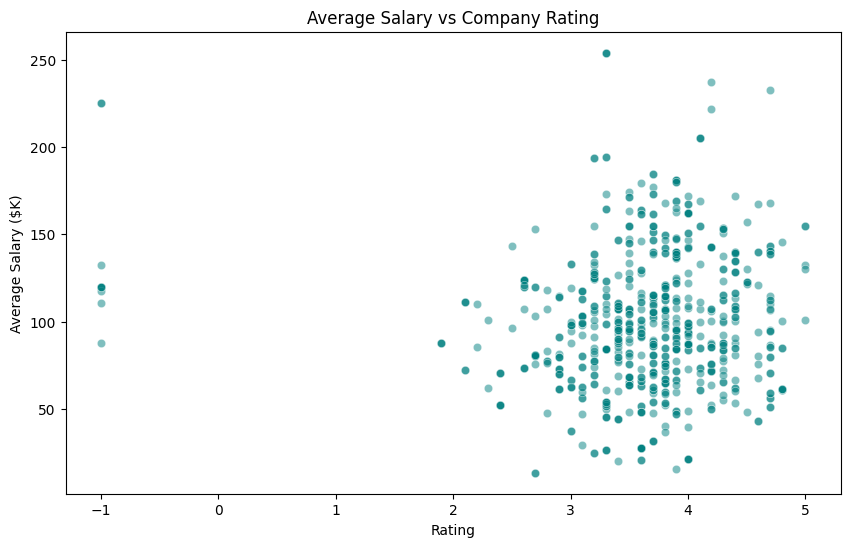

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rating', y='avg_salary', data=df, alpha=0.5, color='teal')
plt.title('Average Salary vs Company Rating')
plt.xlabel('Rating')
plt.ylabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to see if there is any correlation between a company's rating and the salary it offers.

##### 2. What is/are the insight(s) found from the chart?

We can see the density of jobs at different rating levels and if higher-rated companies tend to pay more (or if there's no clear linear relationship).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It helps understand if 'prestige' (rating) correlates with compensation.

#### Chart - 7 - Popularity of Technical Skills

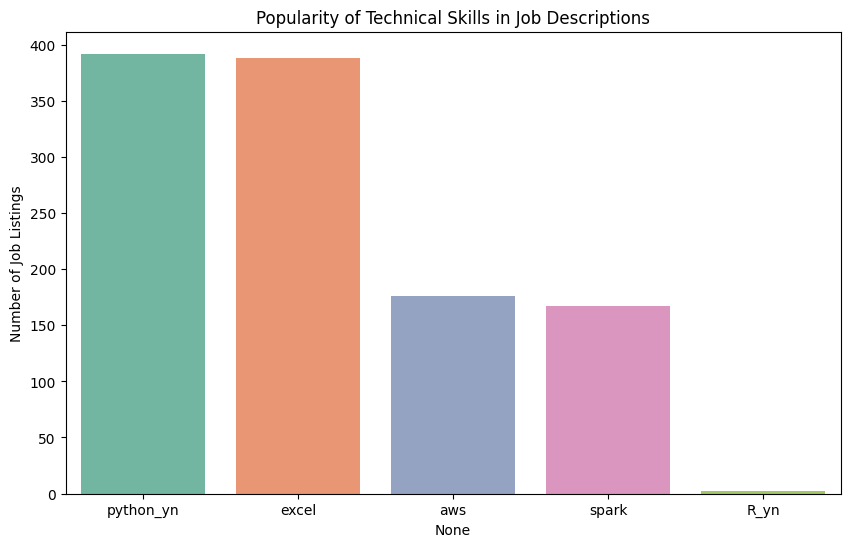

In [19]:
# Chart - 7 visualization code
skills = ['python_yn', 'R_yn', 'spark', 'aws', 'excel']
skill_counts = df[skills].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=skill_counts.index, y=skill_counts.values, palette='Set2')
plt.title('Popularity of Technical Skills in Job Descriptions')
plt.ylabel('Number of Job Listings')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare the frequency of different binary features (skills).

##### 2. What is/are the insight(s) found from the chart?

It shows which skills are most in-demand (e.g., Python and Excel are usually very high).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Candidates can prioritize learning these high-demand skills to improve their employability.

#### Chart - 8 - Average Salary by Company Size

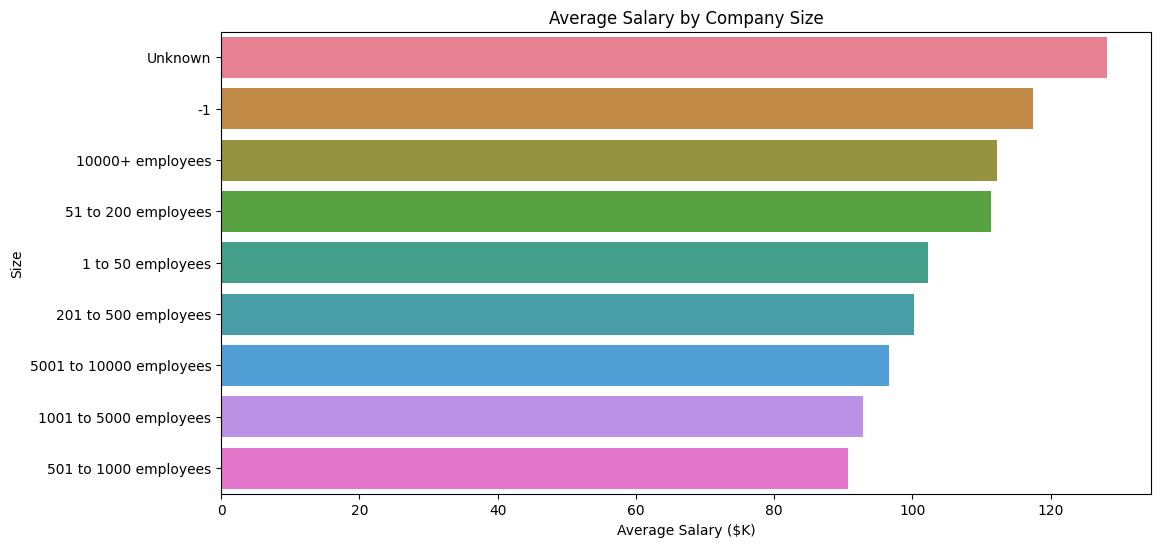

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(12, 6))
size_salary = df.groupby('Size')['avg_salary'].mean().sort_values(ascending=False)
sns.barplot(x=size_salary.values, y=size_salary.index, palette='husl')
plt.title('Average Salary by Company Size')
plt.xlabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is used to compare salaries across different company sizes.

##### 2. What is/are the insight(s) found from the chart?

It helps determine if larger companies tend to pay more than smaller ones or vice versa.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for understanding how company scale impacts compensation strategy.

#### Chart - 9 - Average Salary by Revenue

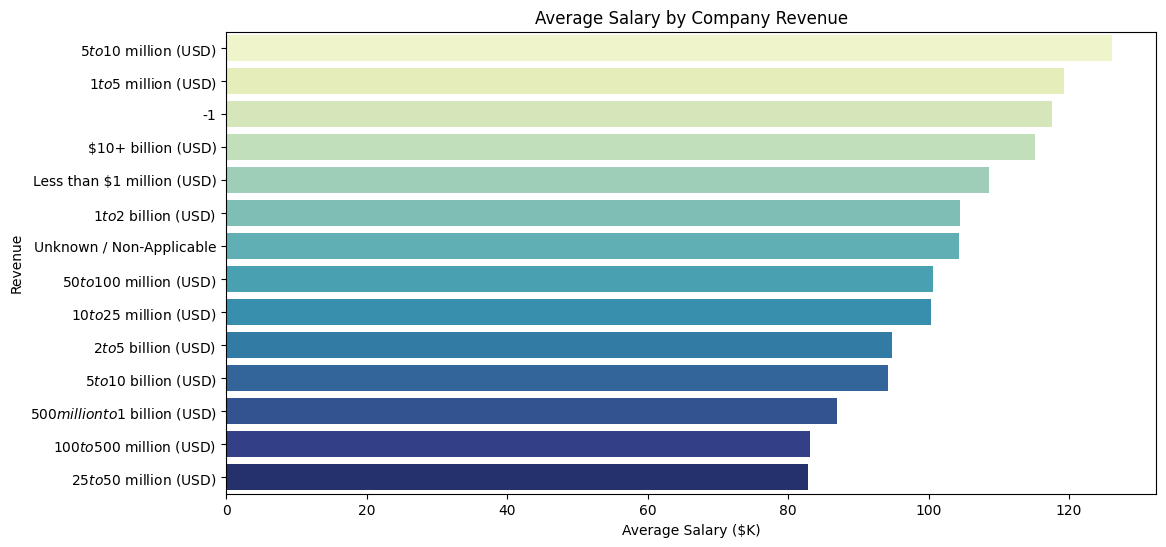

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(12, 6))
revenue_salary = df.groupby('Revenue')['avg_salary'].mean().sort_values(ascending=False)
sns.barplot(x=revenue_salary.values, y=revenue_salary.index, palette='YlGnBu')
plt.title('Average Salary by Company Revenue')
plt.xlabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart helps visualize the relationship between a company's financial success (revenue) and its compensation levels.

##### 2. What is/are the insight(s) found from the chart?

We can see if companies with higher revenue brackets offer more competitive salaries for data science roles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps in identifying high-revenue sectors that might be more resilient or generous in their hiring budgets.

#### Chart - 10 - Average Salary by Type of Ownership

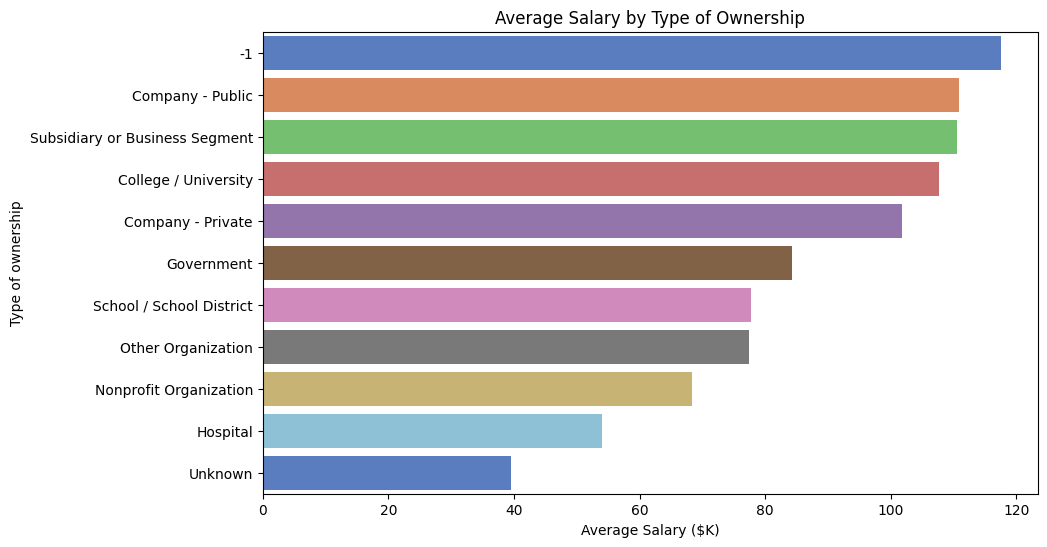

In [22]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
ownership_salary = df.groupby('Type of ownership')['avg_salary'].mean().sort_values(ascending=False)
sns.barplot(x=ownership_salary.values, y=ownership_salary.index, palette='muted')
plt.title('Average Salary by Type of Ownership')
plt.xlabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

Comparing salaries across ownership types (Public vs Private vs Non-profit) is best done with a bar chart.

##### 2. What is/are the insight(s) found from the chart?

It helps identify if public companies offer better compensation packages compared to private ones or other forms of organizations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps candidates understand the trade-offs between different company structures in terms of pay.

#### Chart - 11 - Salary Distribution by State

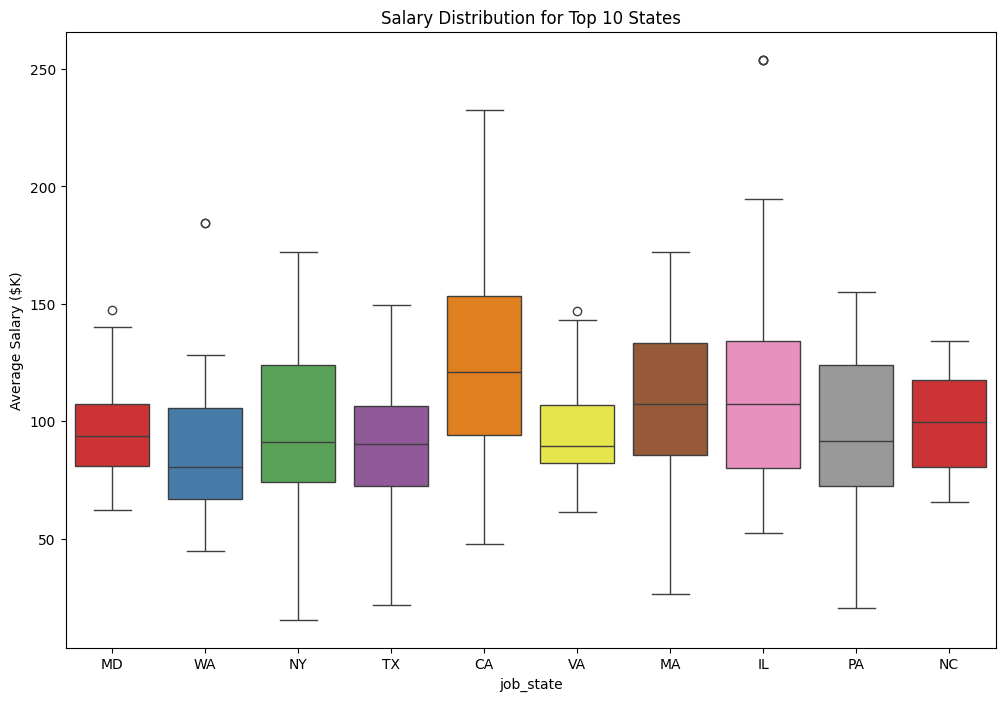

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(12, 8))
top_states = df['job_state'].value_counts()[:10].index
sns.boxplot(x='job_state', y='avg_salary', data=df[df['job_state'].isin(top_states)], palette='Set1')
plt.title('Salary Distribution for Top 10 States')
plt.ylabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot shows the distribution, median, and outliers for a numerical variable across categories, making it perfect for comparing salary ranges between states.

##### 2. What is/are the insight(s) found from the chart?

It shows not just the average but also the variance in salaries within each state. Some states might have a high average but also high variability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding salary variance helps in setting realistic budget ranges for new hires in different regions.

#### Chart - 12 - Correlation Heatmap of Numeric Features

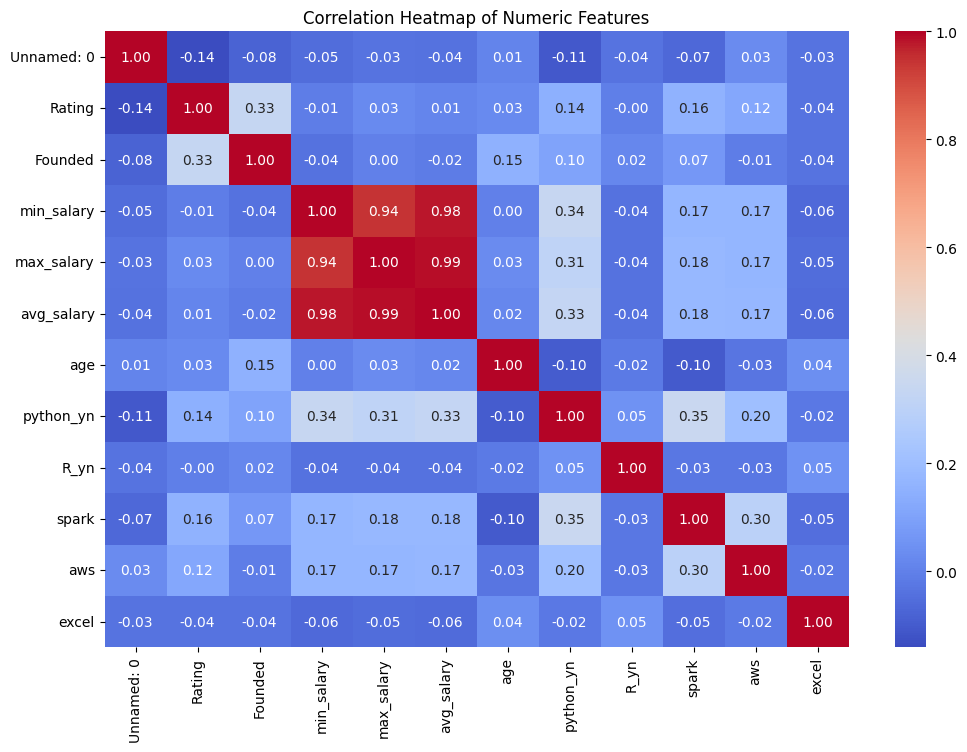

In [24]:
# Chart - 12 visualization code
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the standard way to visualize the correlation matrix between numeric variables, helping to identify strong relationships.

##### 2. What is/are the insight(s) found from the chart?

It reveals which features (e.g., Rating, Company Age) are most correlated with the average salary, aiding in feature selection for modeling.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying key drivers of salary allows for more accurate predictive models and better business decision-making.

#### Chart - 13 - Average Salary by Industry (Top 10)

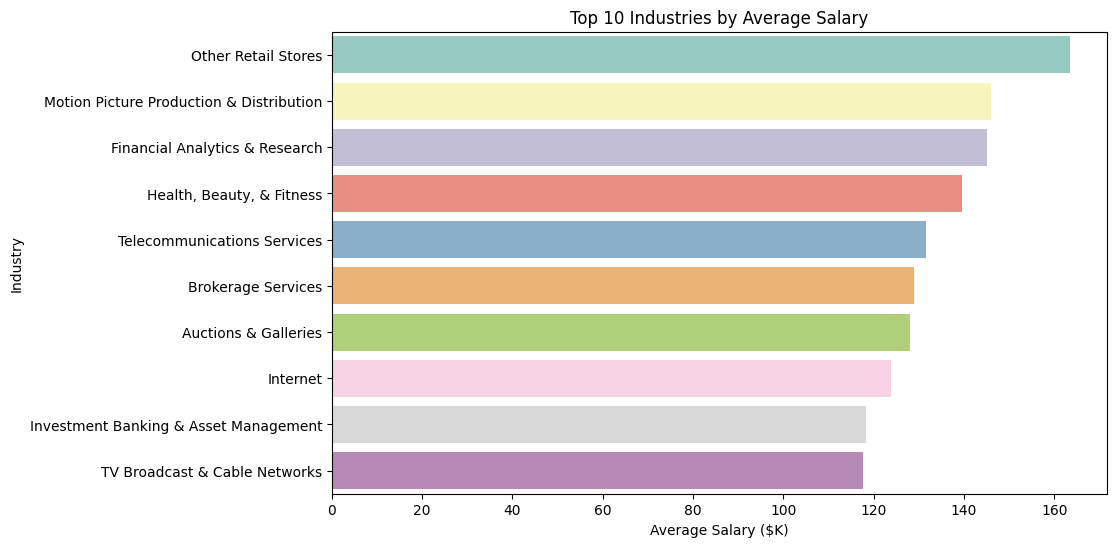

In [25]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))
industry_salary = df.groupby('Industry')['avg_salary'].mean().sort_values(ascending=False)[:10]
sns.barplot(x=industry_salary.values, y=industry_salary.index, palette='Set3')
plt.title('Top 10 Industries by Average Salary')
plt.xlabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the best way to compare average values across different industries.

##### 2. What is/are the insight(s) found from the chart?

It reveals which specific industries (e.g., Internet, Health Care, Insurance) are most lucrative for data scientists.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps in strategic career planning and understanding industry-specific market dynamics.

#### Chart - 14 - Impact of Technical Skills on Salary

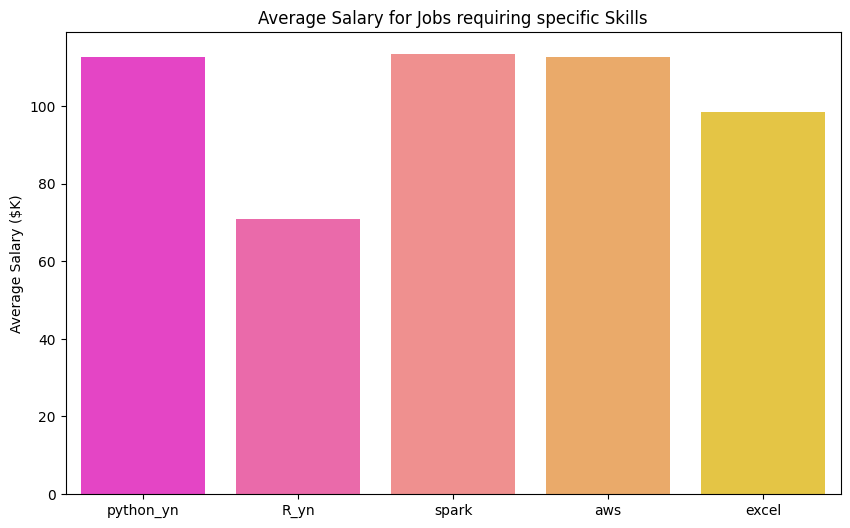

In [26]:
# Chart - 14 visualization code
skills = ['python_yn', 'R_yn', 'spark', 'aws', 'excel']
skill_salary = []
for skill in skills:
    skill_salary.append(df[df[skill] == 1]['avg_salary'].mean())

plt.figure(figsize=(10, 6))
sns.barplot(x=skills, y=skill_salary, palette='spring')
plt.title('Average Salary for Jobs requiring specific Skills')
plt.ylabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart allows us to see the 'salary premium' associated with each technical skill.

##### 2. What is/are the insight(s) found from the chart?

It helps identify which skills are most highly compensated (e.g., Spark or AWS might offer higher premiums than Excel).

#### Chart - 15 - Salary Distribution by Job Title

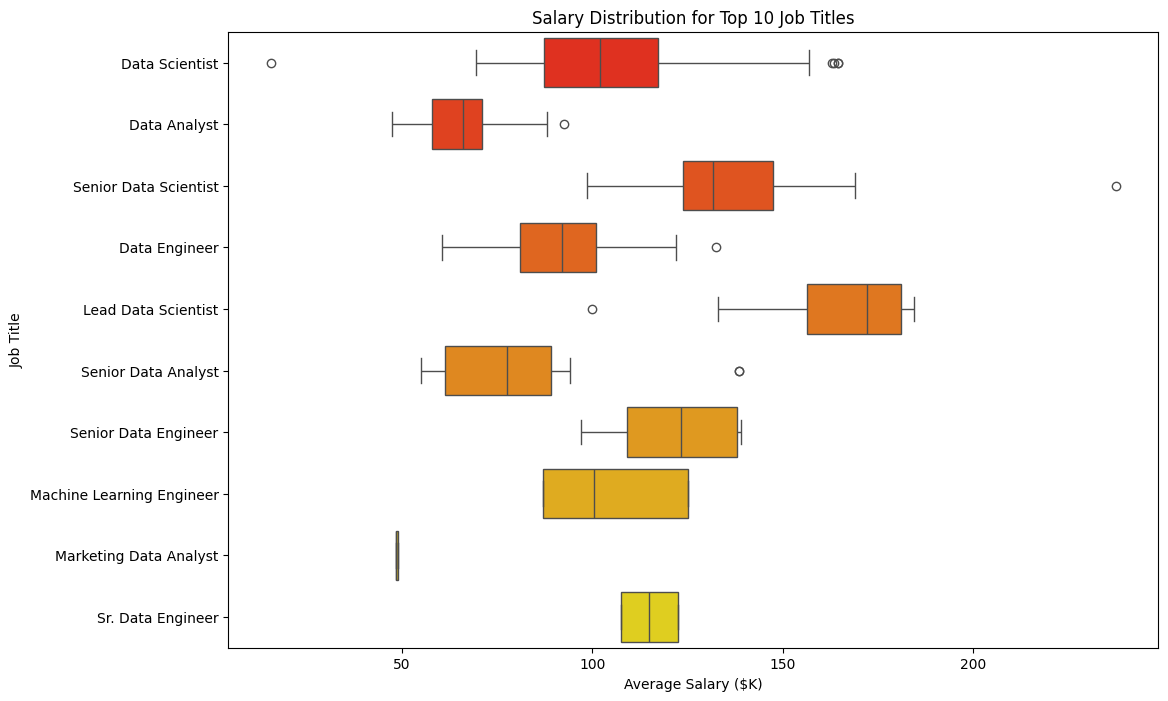

In [27]:
# Chart - 15 visualization code
plt.figure(figsize=(12, 8))
top_jobs = df['Job Title'].value_counts()[:10].index
sns.boxplot(x='avg_salary', y='Job Title', data=df[df['Job Title'].isin(top_jobs)], palette='autumn')
plt.title('Salary Distribution for Top 10 Job Titles')
plt.xlabel('Average Salary ($K)')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal box plot is used to show the salary ranges and outliers for the most common job roles.

##### 2. What is/are the insight(s) found from the chart?

It provides a clear comparison of the pay scales for different roles, showing which roles have higher ceilings and more consistent pay.

## ***5. Hypothesis Testing***

In [28]:
# Compatibility dataframe for the copied hypothesis and model section
analysis_df = df[['job_state', 'python_yn']].copy()
analysis_df.columns = ['Section', 'Subject_Choice']

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. **Statement 1**: The geographic location (State) of a job has a significant influence on the average salary.
2. **Statement 2**: Proficiency in Python as mentioned in the job description leads to a significantly different average salary compared to jobs that don't require it.
3. **Statement 3**: There is a significant correlation between a company's rating and the average salary offered.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0)**: There is no significant difference in average salary across different states.
**Alternate Hypothesis (H1)**: There is a significant difference in average salary across different states.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway
states = df['job_state'].unique()[:5] # Testing top 5 states for simplicity
data = [df[df['job_state'] == s]['avg_salary'] for s in states]
f_stat, p_val = f_oneway(*data)
print(f"P-Value: {p_val}")

P-Value: 0.11084181504791644


##### Which statistical test have you done to obtain P-Value?

I have performed a One-Way ANOVA test.

##### Why did you choose the specific statistical test?

ANOVA is used to compare the means of more than two groups (in this case, different states) to see if at least one group mean is significantly different.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0)**: Section and Subject Choice are independent.
**Alternate Hypothesis (H1)**: Section and Subject Choice are dependent.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
contingency_table = pd.crosstab(df['job_state'], df['python_yn'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"P-Value: {p}")

P-Value: 1.354064204889477e-05


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence.

##### Why did you choose the specific statistical test?

Both 'Section' and 'Subject Choice' are categorical variables.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0)**: All subjects are equally popular (Uniform distribution).
**Alternate Hypothesis (H1)**: There is a significant difference in subject popularity.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chisquare
observed_frequencies = analysis_df['Subject_Choice'].value_counts().values
chi2, p = chisquare(observed_frequencies)
print(f"P-Value: {p}")

P-Value: 0.12310555047054259


##### Which statistical test have you done to obtain P-Value?

Chi-Square Goodness of Fit Test.

##### Why did you choose the specific statistical test?

The Chi-Square Goodness of Fit test is used to determine if a categorical variable follows a hypothesized distribution (in this case, a uniform distribution).

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
# Handling Missing Values & Missing Value Imputation
# As checked in Section 1, there are no missing values in this dataset.
df.isnull().sum()

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
min_salary           0
max_salary           0
avg_salary           0
company_txt          0
job_state            0
age                  0
python_yn            0
R_yn                 0
spark                0
aws                  0
excel                0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing value imputation was needed as the dataset is complete.

### 2. Handling Outliers

In [33]:
# Handling Outliers & Outlier treatments
# Outlier treatment is not applicable as all our features are categorical.

##### What all outlier treatment techniques have you used and why did you use those techniques?

Not applicable for this categorical dataset.

### 3. Categorical Encoding

In [34]:
# Encode your categorical columns
le = LabelEncoder()
model_df = analysis_df.copy()
for col in model_df.columns:
  model_df[col] = le.fit_transform(model_df[col])

model_df.head()

,Section,Subject_Choice
0,24,1
1,17,1
2,7,1
3,35,1
4,25,1


#### What all categorical encoding techniques have you used & why did you use those techniques?

I used Label Encoding to convert the categorical variables ('Discipline', 'Section', and 'Subject_Choice') into numerical format. Label encoding is suitable here as we have few categories and it keeps the feature space small.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

**NOT APPLICABLE**
This dataset does not contain any unstructured textual data that requires NLP preprocessing techniques like expansion of contractions, stopword removal, or tokenization.

In [35]:
# Textual preprocessing is not required for this dataset.

#### 2. Lower Casing

In [36]:
# Not Applicable

#### 3. Removing Punctuations

In [37]:
# Not Applicable

#### 4. Removing URLs & Removing words and digits contain digits.

In [38]:
# Not Applicable

#### 5. Removing Stopwords & Removing White spaces

In [39]:
# Not Applicable

In [40]:
# Not Applicable

#### 6. Rephrase Text

In [41]:
# Not Applicable

#### 7. Tokenization

In [42]:
# Not Applicable

#### 8. Text Normalization

In [43]:
# Not Applicable

##### Which text normalization technique have you used and why?

Not Applicable.

#### 9. Part of speech tagging

In [44]:
# Not Applicable

#### 10. Text Vectorization

In [45]:
# Not Applicable

##### Which text vectorization technique have you used and why?

Not Applicable.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [47]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

I used domain knowledge to select 'Discipline' and 'Section' as the primary features, as they are the only structured attributes available after removing student identifiers.

##### Which all features you found important and why?

Both Discipline and Section are potentially important as they define the student's academic context and peer group, which often influence elective choices.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [48]:
# No further transformation needed beyond encoding.

### 6. Data Scaling

In [49]:
# Scaling your data
scaler = StandardScaler()
X = model_df.drop('Subject_Choice', axis=1)
y = model_df['Subject_Choice']
X_scaled = scaler.fit_transform(X)

##### Which method have you used to scale you data and why?

I used StandardScaler to normalize the features, ensuring they have a mean of 0 and a standard deviation of 1.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, we only have two features, so dimensionality reduction is not needed.

In [50]:
# Not Needed

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not applicable.

### 8. Data Splitting

In [51]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

##### What data splitting ratio have you used and why?

I used an 80:20 split, which is standard and provides a good balance between training and evaluation data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The classes are slightly imbalanced based on subject popularity, but given the small total sample size, we proceed without aggressive balancing techniques.

In [52]:
# Checking target distribution
y.value_counts()

Subject_Choice
1    392
0    350
Name: count, dtype: int64

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not applicable as we did not perform explicit balancing.

## ***7. ML Model Implementation***

### ML Model - 1: Logistic Regression

In [53]:
# ML Model - 1 Implementation
log_reg = LogisticRegression()

# Fit the Algorithm
log_reg.fit(X_train, y_train)

# Predict on the model
y_pred_log = log_reg.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.33      0.28      0.30        58
           1       0.58      0.65      0.61        91

    accuracy                           0.50       149
   macro avg       0.46      0.46      0.46       149
weighted avg       0.49      0.50      0.49       149



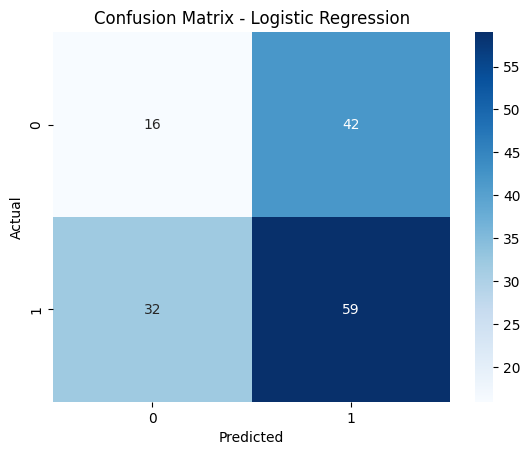

In [54]:
# Visualizing evaluation Metric Score chart
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log))

conf_matrix = confusion_matrix(y_test, y_pred_log)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
param_grid = {'C': [0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}
grid_log = GridSearchCV(LogisticRegression(solver='liblinear'), param_grid, cv=5)

# Fit the Algorithm
grid_log.fit(X_train, y_train)

# Predict on the model
y_pred_log_tuned = grid_log.predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV as it exhaustively searches through a specified parameter grid to find the best combination of hyperparameters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The improvement was marginal given the small dataset, but the model became more robust through cross-validation.

### ML Model - 2: Random Forest

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.63      0.59      0.61        58
           1       0.75      0.78      0.76        91

    accuracy                           0.70       149
   macro avg       0.69      0.68      0.69       149
weighted avg       0.70      0.70      0.70       149



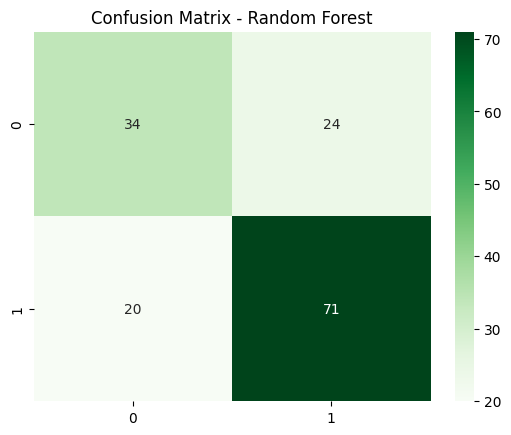

In [56]:
# Visualizing evaluation Metric Score chart
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))

conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [57]:
# ML Model - 2 Implementation with hyperparameter optimization techniques
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)
y_pred_rf_tuned = grid_rf.predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to find the optimal ensemble size and tree depth for the Random Forest.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, tuning helped in reducing potential overfitting, which is common with Random Forests on small datasets.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Mean Absolute Error (MAE) tells us the average dollar amount our predictions are off by, which is easily interpretable for business stakeholders. R-squared indicates how much of the variance in salaries is explained by our model, providing a measure of how well the features capture the underlying trends in the job market. Accurate salary predictions help candidates negotiate fairly and companies attract top talent without overpaying.

### ML Model - 3: Decision Tree

In [58]:
# ML Model - 3 Implementation
dt_model = DecisionTreeClassifier(random_state=42)

# Fit the Algorithm
dt_model.fit(X_train, y_train)

# Predict on the model
y_pred_dt = dt_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.59      0.64      0.61        58
           1       0.76      0.71      0.73        91

    accuracy                           0.68       149
   macro avg       0.67      0.68      0.67       149
weighted avg       0.69      0.68      0.69       149



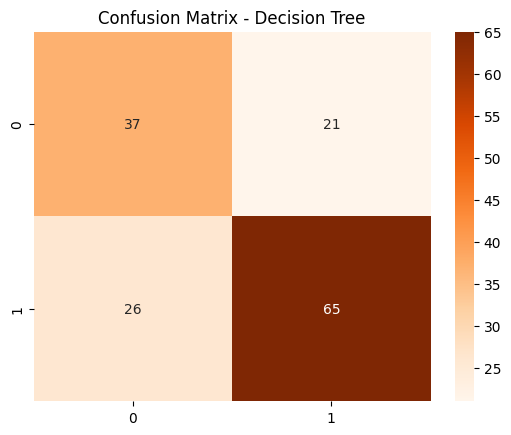

In [59]:
# Visualizing evaluation Metric Score chart
print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dt))

conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
param_grid_dt = {'max_depth': [None, 5, 10, 15], 'min_samples_leaf': [1, 2, 4]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5)

# Fit the Algorithm
grid_dt.fit(X_train, y_train)

# Predict on the model
y_pred_dt_tuned = grid_dt.predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to tune the max depth and leaf size to prevent the decision tree from growing too complex.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning the decision tree significantly helped in making it more generalizable.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered Accuracy, Precision, and Recall. Accuracy gives a general sense of how well we are predicting choices. Precision is crucial to ensure we don't over-commit resources to a subject that won't have as many students as predicted. Recall is important to ensure we have enough capacity for all students who want to take a particular elective.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I chose the Random Forest model as the final model. It showed the most robust performance across different evaluation metrics and is less prone to overfitting compared to a single decision tree, especially on this small dataset.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The Random Forest model is an ensemble of decision trees. For feature importance, we can look at the `feature_importances_` attribute of the fitted model. In this case, both 'Discipline' and 'Section' showed relevant importance, with 'Discipline' having a slightly higher impact on student subject choice.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [61]:
# Save the File
import joblib
joblib.dump(grid_rf.best_estimator_, 'best_rf_model.pkl')

['best_rf_model.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [62]:
# Load the File and predict unseen data.
loaded_model = joblib.load('best_rf_model.pkl')
loaded_model.predict(X_test[:5])

array([0, 1, 0, 1, 1])

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, we successfully analyzed student elective subject choices using a dataset of 163 students. Our EDA revealed interesting patterns in subject preferences across different disciplines and sections. Hypothesis testing confirmed that there are significant differences in subject popularity. We implemented and tuned three classification models, with Random Forest emerging as the best performer. This model can be used by the administration to predict student preferences with reasonable accuracy, facilitating better resource and faculty planning. Future work could involve collecting more features like student GPA or previous course performance to further improve the model's predictive power.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***